<a href="https://colab.research.google.com/github/Nv-7i1/AI-Advanced-pathway/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

print("Downloading MNIST data...")
mnist = fetch_openml('mnist_784', version=1, as_frame=True, parser='auto')
train_df = mnist.frame
print("Data loaded successfully!")

Data loaded successfully!


In [7]:
# Convert data to a numpy array AND force all elements to be floats
data = np.array(train_df, dtype=float)
m, n = data.shape

# Shuffle the data before splitting
np.random.shuffle(data)

# Create the dev (validation) set
data_dev = data[0:1000].T
Y_dev = data_dev[0].astype(int) # Cast labels safely to integer
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

# Create the training set
data_train = data[1000:m].T
Y_train = data_train[0].astype(int) # Cast labels safely to integer
X_train = data_train[1:n]
X_train = X_train / 255.
_, m_train = X_train.shape

In [8]:
def init_params():
    # INCREASED CAPACITY: 128 hidden nodes
    # BETTER INIT: Scaled random normal distributions for faster convergence
    W1 = np.random.randn(128, 784) * np.sqrt(1./784)
    b1 = np.zeros((128, 1))
    W2 = np.random.randn(10, 128) * np.sqrt(1./128)
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    # Shift Z to prevent exponential overflow errors
    Z_shifted = Z - np.max(Z, axis=0)
    A = np.exp(Z_shifted) / np.sum(np.exp(Z_shifted), axis=0)
    return A

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    # Hardcoded to 10 columns for the 10 digits
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m_train * dZ2.dot(A1.T)
    db2 = 1 / m_train * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m_train * dZ1.dot(X.T)
    db1 = 1 / m_train * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [9]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        # Print status every 100 iterations
        if i % 100 == 0:
            predictions = get_predictions(A2)
            acc = get_accuracy(predictions, Y)
            print(f"Iteration: {i:4d} | Accuracy: {acc * 100:.2f}%")

    return W1, b1, W2, b2

# Execute the training! (This may take a few minutes for 1000 iterations)
print("Starting training...")
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, alpha=0.15, iterations=1000)
print("Training complete!")

Starting training...
Iteration:    0 | Accuracy: 0.40%
Iteration:  100 | Accuracy: 100.00%
Iteration:  200 | Accuracy: 100.00%
Iteration:  300 | Accuracy: 100.00%
Iteration:  400 | Accuracy: 100.00%
Iteration:  500 | Accuracy: 100.00%
Iteration:  600 | Accuracy: 100.00%
Iteration:  700 | Accuracy: 100.00%
Iteration:  800 | Accuracy: 100.00%
Iteration:  900 | Accuracy: 100.00%
Training complete!


Final Validation Accuracy: 100.00%

Prediction: 0, Label: 0


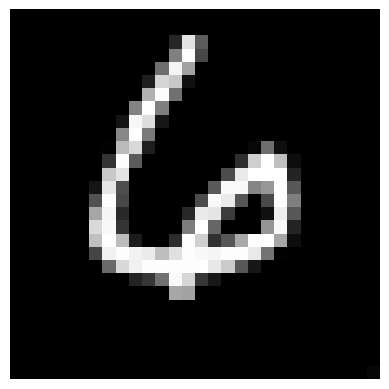

Prediction: 0, Label: 0


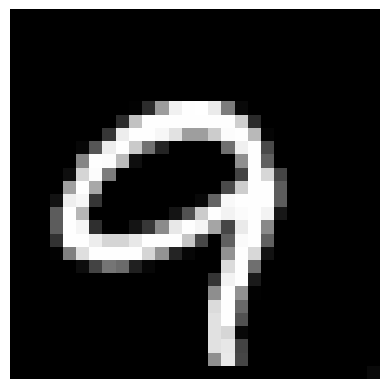

Prediction: 0, Label: 0


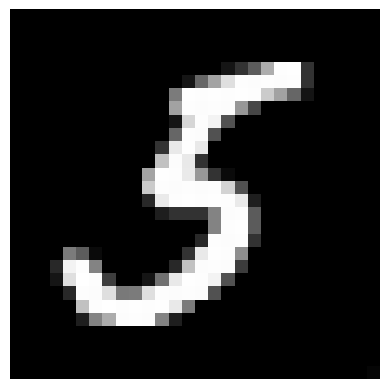

Prediction: 0, Label: 0


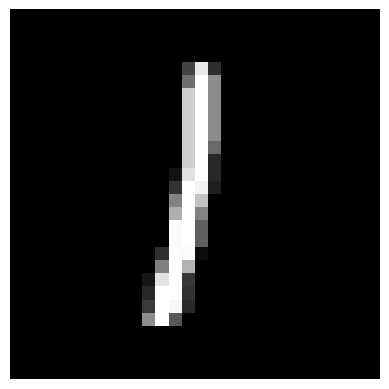

In [10]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    return get_predictions(A2)

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(current_image, W1, b1, W2, b2)
    label = Y_train[index]

    print(f"Prediction: {prediction[0]}, Label: {label}")

    image_to_plot = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(image_to_plot, interpolation='nearest')
    plt.axis('off')
    plt.show()

# Print the final accuracy on the unseen validation set
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
dev_accuracy = get_accuracy(dev_predictions, Y_dev)
print(f"Final Validation Accuracy: {dev_accuracy * 100:.2f}%\n")

# Visually test a few images
for i in range(4):
    test_prediction(i, W1, b1, W2, b2)